# Used Car Prediction (Multiple Linear Regression)

# Problem Statement
 - The objective of this project is to analyze the factors that influence the selling price of used cars and develop a machine learning model capable of accurately predicting the price of a used vehicle based on its characteristics.

# Business Problem

 - The value of a used car depends on several factors such as the vehicle's age, brand, fuel type, transmission type, mileage, engine specifications, and ownership history. Accurately predicting used car prices helps buyers, sellers, dealerships, and online automobile platforms make informed pricing decisions and improve market transparency

# 📈 Workflow Architecture

# 📊 Data Structure

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load Data

In [ ]:
df=pd.read_csv(r'scrap price.csv')
df

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


# Data Understanding

In [3]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
df.tail()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0
204,205,-1,volvo 264gl,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,19,25,22625.0


In [5]:
print(f'Number of Rows: {df.shape[0]}')
print(f'Number of Columns: {df.shape[1]}')

Number of Rows: 205
Number of Columns: 26


In [6]:
df.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
df.describe()

,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [9]:
df.describe(include=object)

,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,toyota corona,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


# Spliting Name column into Brand and Brand Model Name(Name)

In [10]:
df[['Brand','Name']]=df['name'].str.split(' ',n=1,expand=True)
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,Brand,Name
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero,giulia
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero,stelvio
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero,Quadrifoglio
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,audi,100 ls
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,audi,100ls


In [11]:
df.drop(columns=['name'],inplace=True)

# Setting Target Column as Last Columns

In [12]:
df=df[['ID', 'symboling','Brand','Name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']]

In [13]:
df.head()

,ID,symboling,Brand,Name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,giulia,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,stelvio,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,Quadrifoglio,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,100 ls,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,100ls,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


# Data Quality Checks

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isna().sum()

ID                  0
symboling           0
Brand               0
Name                2
fueltypes           0
aspiration          0
doornumbers         0
carbody             0
drivewheels         0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

# EDA

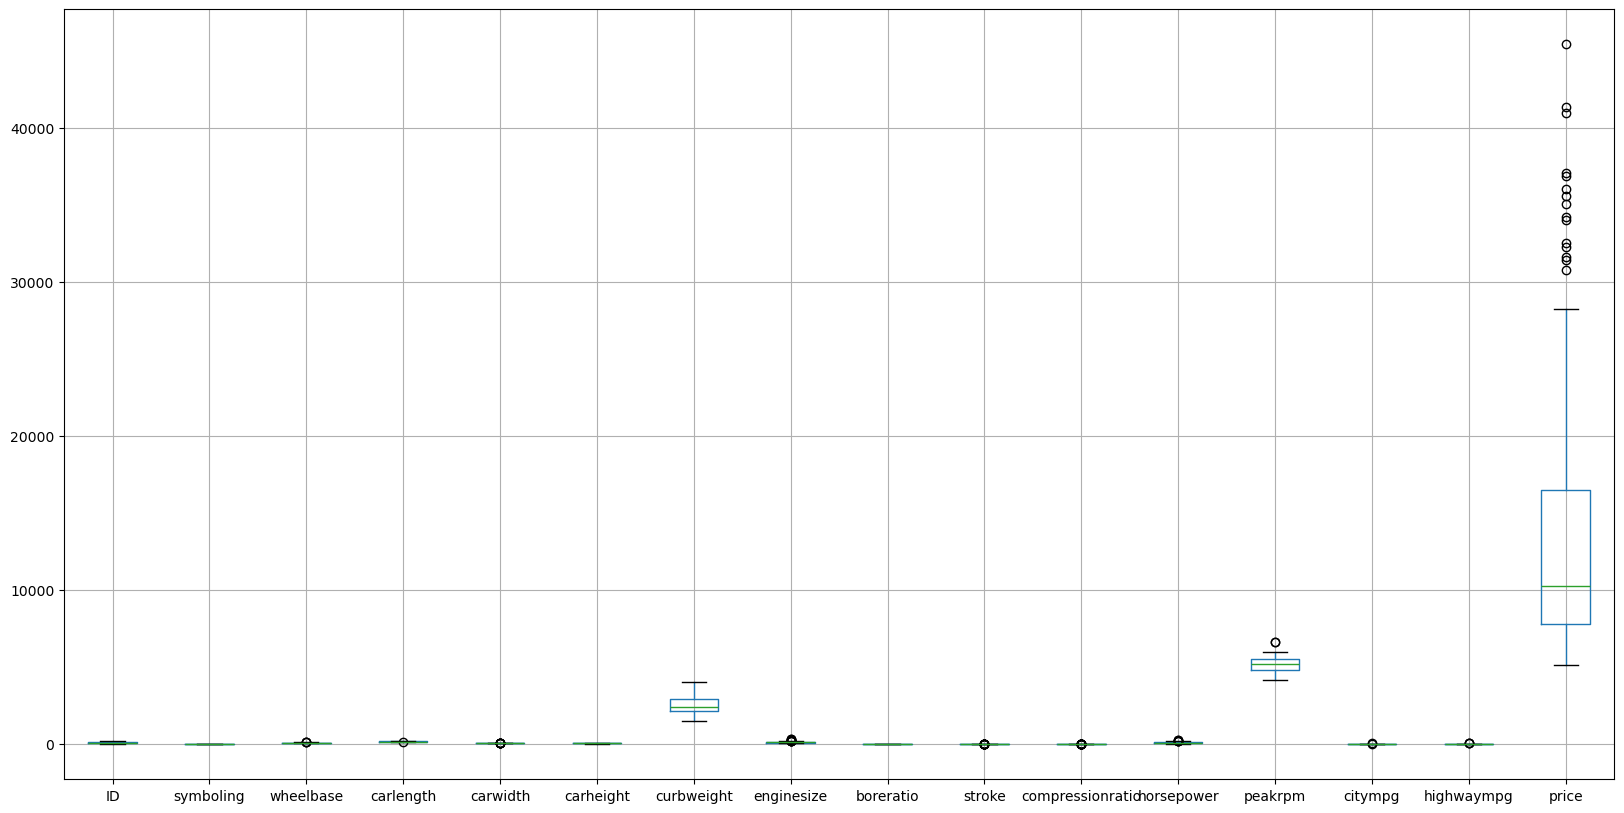

In [16]:
plt.figure(figsize=(20,10))
df.boxplot()
plt.show()

# Encoding

In [17]:
df.head()

,ID,symboling,Brand,Name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,giulia,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,stelvio,gas,std,two,convertible,rwd,front,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,Quadrifoglio,gas,std,two,hatchback,rwd,front,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,100 ls,gas,std,four,sedan,fwd,front,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,100ls,gas,std,four,sedan,4wd,front,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [18]:
for i in df.columns:
            print(f'{i}:{df[i].unique()}')

ID:[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205]
symboling:[ 3  1  2  0 -1 -2]
Brand:['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'maxda' 'mazda' 'buick' 'mercury' 'mitsubishi' 'Nissan

# Ordinal Encoding
 - Ordinal Encoding is a categorical data encoding technique in which each category is assigned a numerical value based on a meaningful order or ranking.

In [19]:
df['Brand'] = df['Brand'].replace({'maxda':'mazda','toyouta':'toyota','vokswagen':'volkswagen','vw':'volkswagen',
                                   'porcshce':'porsche','Nissan':'nissan'
})
df['Brand']=df['Brand'].map({'chevrolet':0,'dodge':1,'plymouth':2,'renault':3,'isuzu':4,'nissan':5,'toyota':6,
                            'honda':7,'mitsubishi':8,'mazda':9,'volkswagen':10,
                             'subaru':11,'peugeot':12,'saab':13,'mercury':14,'buick':15,'audi':16,
                             'alfa-romero':17,'bmw':18,'volvo':19,'jaguar':20,'porsche':21})

In [20]:
df['fueltypes']=df['fueltypes'].map({'gas':0,'diesel':1})

In [21]:
df['aspiration']=df['aspiration'].map({'std':0,'turbo':1})

In [22]:
df['doornumbers']=df['doornumbers'].map({'four':0,'two':1})

In [23]:
df['carbody']=df['carbody'].map({'hatchback':0,'sedan':1,'wagon':2,'hardtop':3,'convertible':4})

In [24]:
df['enginelocation']=df['enginelocation'].map({'front':0,'rear':1})

In [25]:
df['drivewheels']=df['drivewheels'].map({'fwd':0,'4wd':1,'rwd':2})

In [26]:
df['enginetype']=df['enginetype'].map({'l':0,'ohc':1,'ohcf':2,'ohcv':3,'dohcv':4,'dohc':5,'rotor':6})

In [27]:
df['fuelsystem']=df['fuelsystem'].map({'1bbl' :0,'2bbl':1,'spfi':2,'mfi':3,'4bbl':4,'mpfi':5,'idi' :6,'spdi':7})

In [28]:
df['cylindernumber']=df['cylindernumber'].map({'two':0,'three':1,'four':2,'five':3,'six':4,'eight':5,'twelve':6})

In [29]:
df.drop(columns=['Name'],inplace=True)

In [30]:
df.head()

,ID,symboling,Brand,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,17,0,0,1,4,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,17,0,0,1,4,2,0,88.6,...,130,5,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,17,0,0,1,0,2,0,94.5,...,152,5,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,16,0,0,0,1,0,0,99.8,...,109,5,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,16,0,0,0,1,1,0,99.4,...,136,5,3.19,3.40,8.0,115,5500,18,22,17450.0


# Correlation Analysis

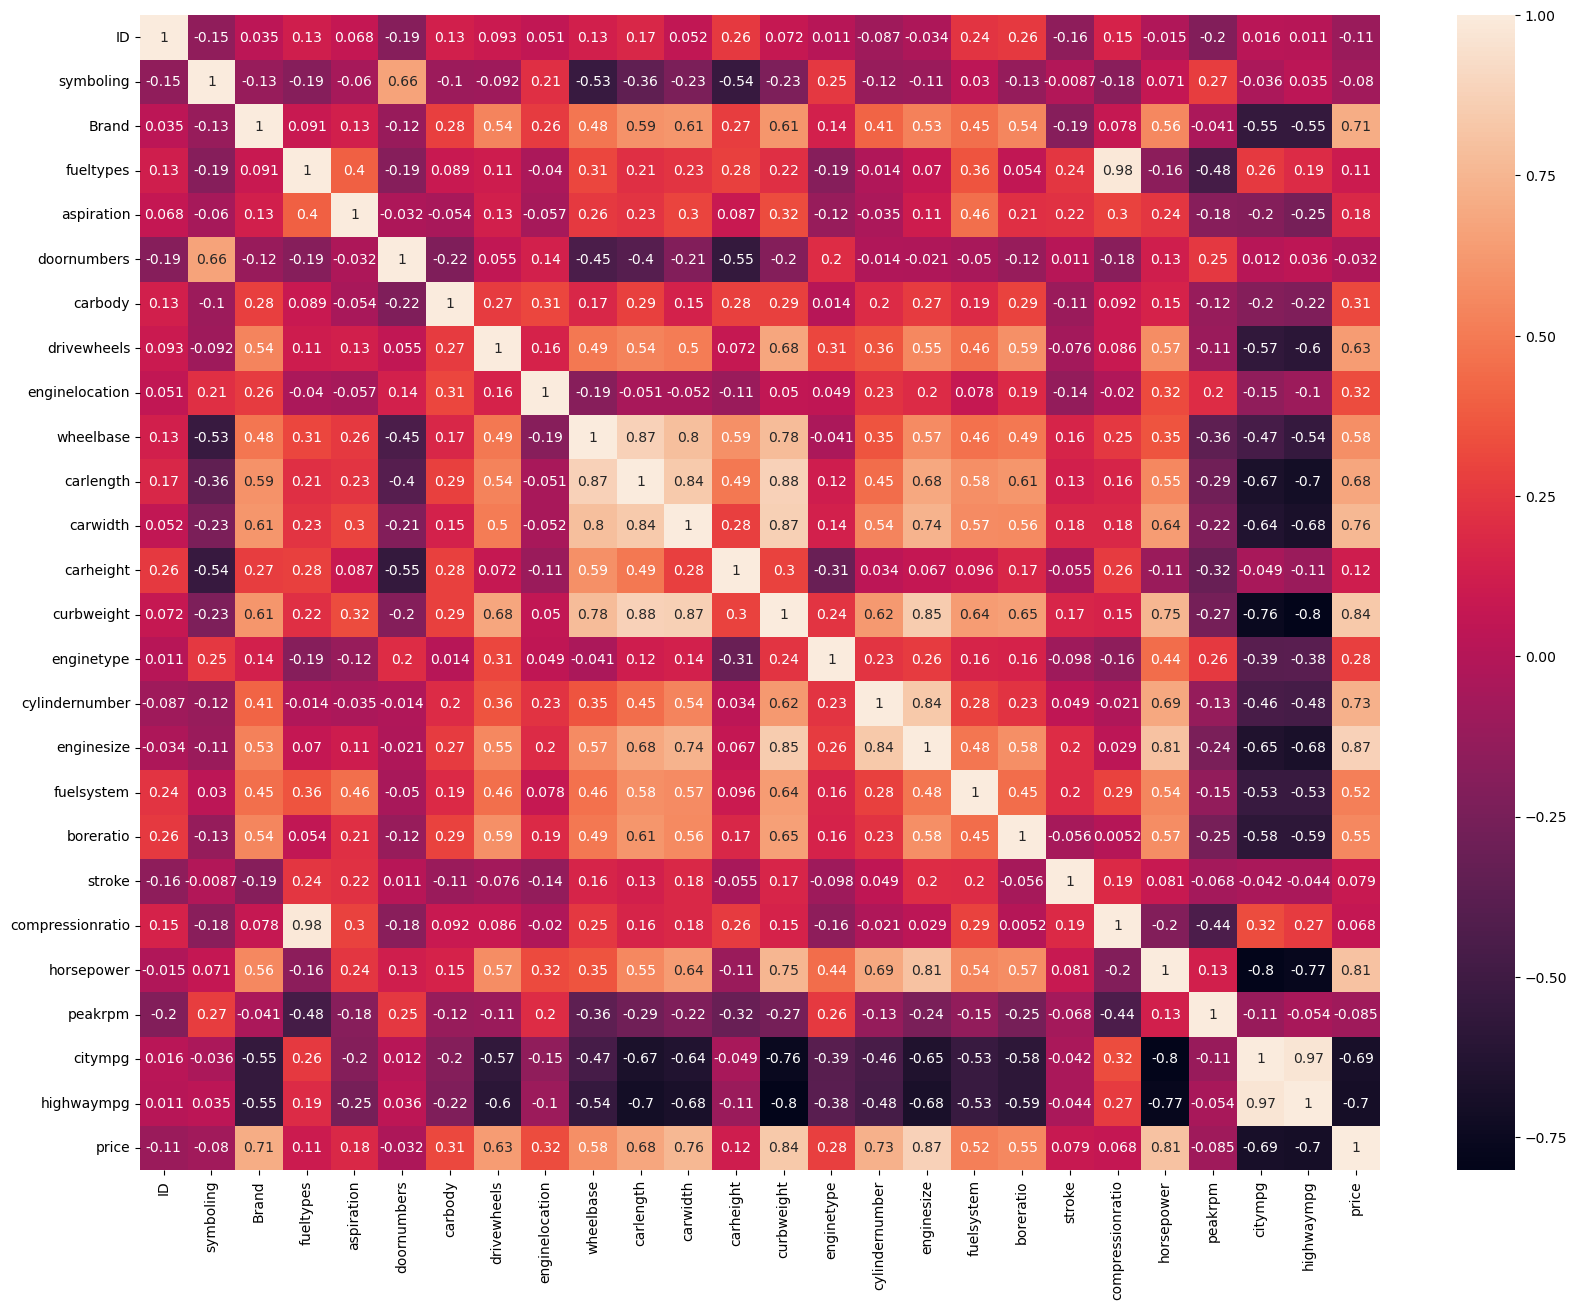

In [31]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

# Below Columns are not that musch correlate with Target Column So Drop it

In [32]:
df.drop(columns=['ID',"symboling",'carheight','citympg','stroke', 'compressionratio',
                 'peakrpm'],inplace=True)

# Feature selection

In [33]:
X=df.drop(columns=['price'])
y=df['price']

# train_test split

In [46]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=0)

# Model Building

In [47]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [48]:
print(f"Coefficient value: {lr.coef_}")
print(f"Slope value: {lr.intercept_}")

Coefficient value: [ 3.19043193e+02  3.29209949e+02  8.04545377e+02 -5.66107253e+02
  4.03585743e+02  1.00202648e+03  1.21341080e+04  1.50531794e+02
 -1.01835736e+02  7.82944579e+02  8.52988988e-01  3.65982623e+02
 -8.12895120e+02  9.81650889e+01 -1.14107609e+02 -5.71326003e+03
  2.35135013e+01 -4.73144149e+01]
Slope value: -34887.247973580415


# Prediction

In [49]:
y_pred=lr.predict(x_test)
y_pred

array([ 7169.36426411, 18860.21359277, 14955.72426585,  -978.09614691,
       10594.7004123 , 13318.79761495,  7590.63968985,  7884.80315783,
       18314.10086828,  8696.797417  , 18225.10733254, 29341.71867992,
       10899.59745174, 14207.12445284,  6326.39520608, 11998.85779528,
        9134.68018497, 19634.64112684,  9206.41792285,  6677.33981693,
        9945.02284987, 15668.74745393,  8216.8181714 , 12137.89500032,
       19607.57602299,  5321.42815367,  7014.18346002, 15957.41521221,
        6787.51351003,  5523.54177488,  9503.63981277, 11389.61824483,
       18687.80144607, 10802.02082307,  6131.44548808, 24203.28222771,
       10930.36727261, 13693.51723923,  4797.35811791, 36826.03574959,
        5730.43333871, 17143.13301889, 30861.51764568, 15781.8456229 ,
       10957.14591677,  6121.74919419,  5863.43886941, 14120.89294043,
       11586.04625103, 10126.04433877, 20942.14257708,  5950.2319984 ,
        7930.91370311,  9979.72113368, 18132.3577765 , 18766.98655376,
      

# Evaluation

In [50]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
print(f'Mean_squared_error: {mse}')
print(f'Root_mean_squared_error: {np.sqrt(mse)}')
print(f'Mean_absolute_error: {mae}')
print(f'R2_score: {r2_score(y_test,y_pred)}')

Mean_squared_error: 9660039.89712943
Root_mean_squared_error: 3108.0604719228727
Mean_absolute_error: 1809.4473498664765
R2_score: 0.8537185865290913


# Score


In [51]:
print(f'Training Accurary: {lr.score(x_train,y_train)}')
print(f'Testing Accuray: {lr.score(x_test,y_test)}')

Training Accurary: 0.9140060025166905
Testing Accuray: 0.8537185865290913


# Conclusion:
- The Multiple Linear Regression model achieved good performance in predicting scrap prices based on the available features.
 - The R² Score of 0.8537 indicates that approximately 85.37% of the variation in scrap prices is explained by the independent variables in the dataset.
 - The Mean Absolute Error (MAE) of 1809.45 shows that the model's predictions differ from the actual scrap prices by about 1,809 units on average.
 - The Root Mean Squared Error (RMSE) of 3108.06 indicates that the typical prediction error is around 3,108 units, suggesting a reasonably accurate model.
 - The Mean Squared Error (MSE) of 9,660,039.90 reflects the overall prediction error and is consistent with the RMSE value.
 - Overall, the model demonstrates strong predictive capability with a high R² score and acceptable error values. It successfully captures the relationship between the input features and scrap prices, making it suitable for estimating scrap prices and supporting data-driven decision-making.